In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
def plotter(input_path, sampler, mode, model,  sample_settings, saving):

    delta_list = [ np.arange(0.25, 0.99, 0.05) if (sampler == "NUTS") else np.arange(0.25, 0.99, 0.1) ][0]

    delta_list_HMC = np.arange(0.25, 0.99, 0.1)
    path_L_for_ESS = []
    path_L_for_h_delta = []
    if ( model== "LR" ):
        path_L_for_ESS = [0.05, 0.075, 0.11, 0.17, 0.26, 0.39, 0.58]
        path_L_for_h_delta = [0.075, 0.17, 0.39, 0.88, 2.0]
        
    elif( model == "HLR" ):
        path_L_for_ESS = [0.03, 0.044, 0.065, 0.097, 0.14, 0.21, 0.31]
        path_L_for_h_delta = [0.044, 0.097, 0.21, 0.46, 1.0]
        
    path_length_list = np.union1d(path_L_for_ESS, path_L_for_h_delta)

    if ( model == "Gauss"): model_fn = "Multivariate Normal"
    elif( model == "LR"): model_fn = "Logistic Regression"
    else: model_fn = "Hierarchical Logistic Regression"
    
    if ( mode == "h-delta"):
        df = pd.read_pickle(input_path)
        if (sampler == "HMC"):
            for val in (path_L_for_h_delta):

                val_df = df[ df["Path Length"] ==  val ]
            
                x_in_graph = val_df["Delta"].values
                
                # Plotting the single-experiment representation
                fig, ax = plt.subplots(figsize=(21,9))
                
                # Plot with errorbars using the combined metrics
                ax.errorbar(
                    x = x_in_graph, 
                    y = val_df["Diff"], 
                    yerr = val_df["MCSE"], 
                    ls="None", 
                    marker=".", 
                    ms=15, 
                    label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
                    color="gray",
                    alpha = 0.5
                )
                
                ax.errorbar(x = delta_list_HMC,
                            y = val_df.groupby(by="Delta").mean()["Diff"],
                            yerr = val_df.groupby(by="Delta")["MCSE"].apply(lambda x: np.sqrt( (x**2).sum()) / sample_settings["reps"] ),
                            ls = "-",
                            marker = "o",
                            ms = 8,
                            label = f"Mean over {sample_settings["reps"]} repetitions",
                            color="red",
                            lw = 2
                )
                
                plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
                plt.ylabel(r" h - $\delta$", fontsize=15)
                plt.title(rf"HMC - {model_fn} - $\epsilon L \approx {val:.2f}$", fontsize=15)
                plt.legend(loc="lower right", fontsize=15)
                plt.axhline(y=0.0, ls="--", color="gray")
                plt.grid(alpha=0.4)
                plt.show()

        else:
            fig, ax = plt.subplots(figsize=(21,9))
            
            x_in_graph = df["Delta"].values
            # Plot with errorbars using the combined metrics
            ax.errorbar(
                x = x_in_graph, 
                y = df["Diff"], 
                yerr = df["MCSE"], 
                ls="None", 
                marker=".", 
                ms=15, 
                label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
                color="gray",
                alpha = 0.5
            )
            ax.errorbar(x = np.unique(df["Delta"]),
                        y = df.groupby(by="Delta").mean()["Diff"],
                        yerr = df.groupby(by="Delta")["MCSE"].apply(lambda x: np.sqrt( (x**2).sum()) / sample_settings["reps"] ),
                        ls = "-",
                        marker = "o",
                        ms = 8,
                        label = f"Mean over {sample_settings["reps"]} repetitions",
                        color="red",
                        lw = 2
            )
            
            plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
            plt.ylabel(r" h - $\delta$", fontsize=15)
            plt.title(f"{sampler} - {model_fn}", fontsize=15)
            plt.legend(loc="lower right", fontsize=15)
            plt.axhline(y=0.0, ls="--", color="gray")
            plt.grid(alpha=0.4)
            if ( saving == True): plt.savefig(f"{model}_{sampler}_{mode}.png")
            plt.show()
        
    elif ( mode == "Ess-per-grad" ):
        df = pd.read_pickle(input_path)
        if ( sampler == "HMC" ):
            for val in (path_L_for_ESS):
                
                val_df = df[ df["Path Length"] ==  val ]
            
                x_in_graph = val_df["Delta"].values
            
                # Plotting the single-experiment representation
                fig, ax = plt.subplots(figsize=(21,9))
                
                # Plot with errorbars using the combined metrics
                ax.plot(
                    x_in_graph, 
                    val_df["Min"], 
                    ls="None", 
                    marker=".", 
                    ms=15, 
                    label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
                    color="gray",
                    alpha = 0.5
                )
                
                ax.plot(delta_list_HMC,
                        val_df.groupby(by="Delta").mean()["Min"],
                        ls = "-",
                        marker = "o",
                        ms = 8,
                        label = f"Mean over {sample_settings["reps"]} repetitions",
                        color="red",
                        lw = 2
                )
                
                plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
                plt.ylabel("ESS per gradient", fontsize=15)
                plt.title(rf"HMC - {model_fn} - $\epsilon L \approx {val:.2f}$", fontsize=15)
                plt.legend(loc="lower right", fontsize=15)
                plt.grid(alpha=0.4)
                plt.show()
                
        else:
            fig, ax = plt.subplots(figsize=(21,9))
            
            x_in_graph = df["Delta"].values
            ax.plot(
                x_in_graph, 
                df["Min"], 
                ls="None", 
                marker=".", 
                ms=15, 
                label=f"Individual Experiment (Averaged across {sample_settings["chains"]} chains)", 
                color="gray",
                alpha = 0.5
            )
            
            ax.plot(np.unique(df["Delta"]),
                    df.groupby(by="Delta").mean()["Min"],
                    ls = "-",
                    marker = "o",
                    ms = 8,
                    label = f"Mean over {sample_settings["reps"]} repetitions",
                    color="red",
                    lw = 2
            )
            
            plt.xlabel(r"Target acceptance rate statistic $\delta$ ", fontsize=15)
            plt.ylabel("ESS per gradient", fontsize=15)
            plt.title(f"{sampler} - {model_fn}", fontsize=15)
            plt.legend(loc="lower right", fontsize=15)
            plt.grid(alpha=0.4)
            if ( saving == True): plt.savefig(f"{model}_{sampler}_{mode}.png")
            plt.show()

    elif ( mode == "Counts"):
        delta_list = np.arange(0.25, 0.99, 0.05)
        show_this_delta = np.arange(0, len(delta_list), 2, dtype="int")
        depths = np.load(input_path)
        
        n_rows = len(show_this_delta)
        
        fig, axes = plt.subplots(n_rows, 1, figsize=(6, 1.5 * n_rows), sharex=True)
        
        # Handle the edge case where show_this_delta has only 1 element
        if n_rows == 1:
            axes = [axes]
        
        x_ticks = np.arange(0, sample_settings["max_treedepth"] + 1, 1)
        x_labels = [fr"$2^{{{k}}}$" for k in range(sample_settings["max_treedepth"] + 1)]
        
        # 3. Populate the vertical grid
        for plot_idx, i in enumerate(show_this_delta):
            ax = axes[plot_idx]
            
            # Draw the bar chart
            ax.bar(x_ticks, depths[i], width=0.9, color="C0", edgecolor="none")
            
            # Always set ticks, but sharex=True will automatically hide labels for upper plots
            ax.set_xticks(x_ticks)
            ax.set_xticklabels(x_labels)
            
            # Y-Label for each specific panel
            ax.set_ylabel("Count")
            
            # Place delta text directly inside the plot panel (top right)
            ax.text(
                0.95, 0.85, 
                fr"$\delta$ = {delta_list[i]:.2f}", 
                transform=ax.transAxes, 
                horizontalalignment="right", 
                verticalalignment="top",
                fontsize=11,
                weight="bold",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none")
            )
        
        # 4. Set the X-label only on the very last (bottom) subplot panel
        axes[-1].set_xlabel("NUTS tree depth")
        
        plt.tight_layout()
        if ( saving == True): plt.savefig(f"{model}_{sampler}_{mode}.png")
        plt.show()

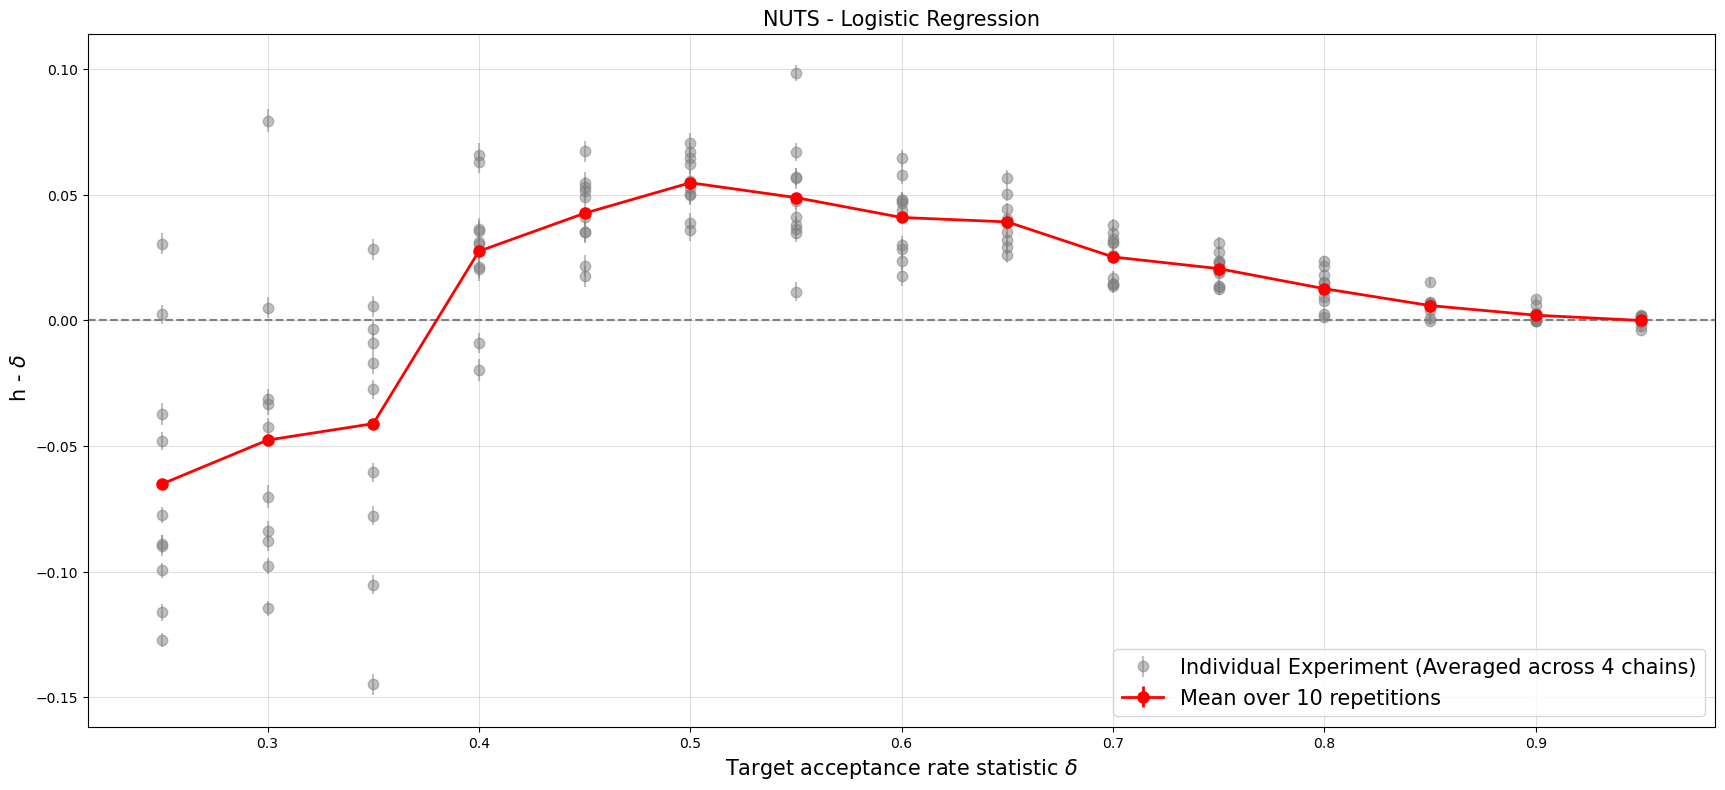

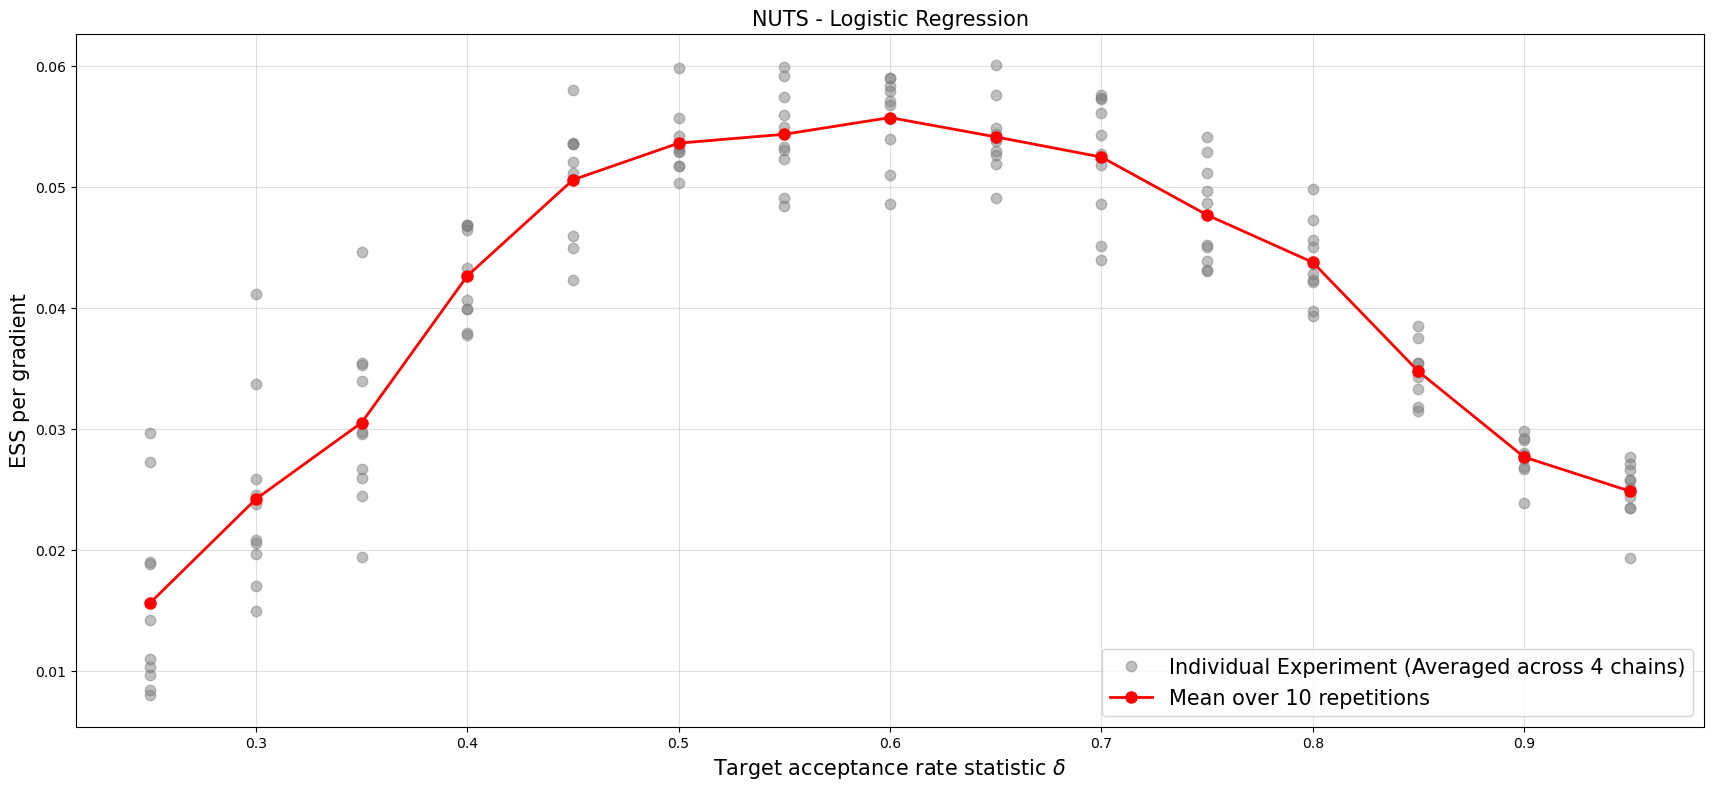

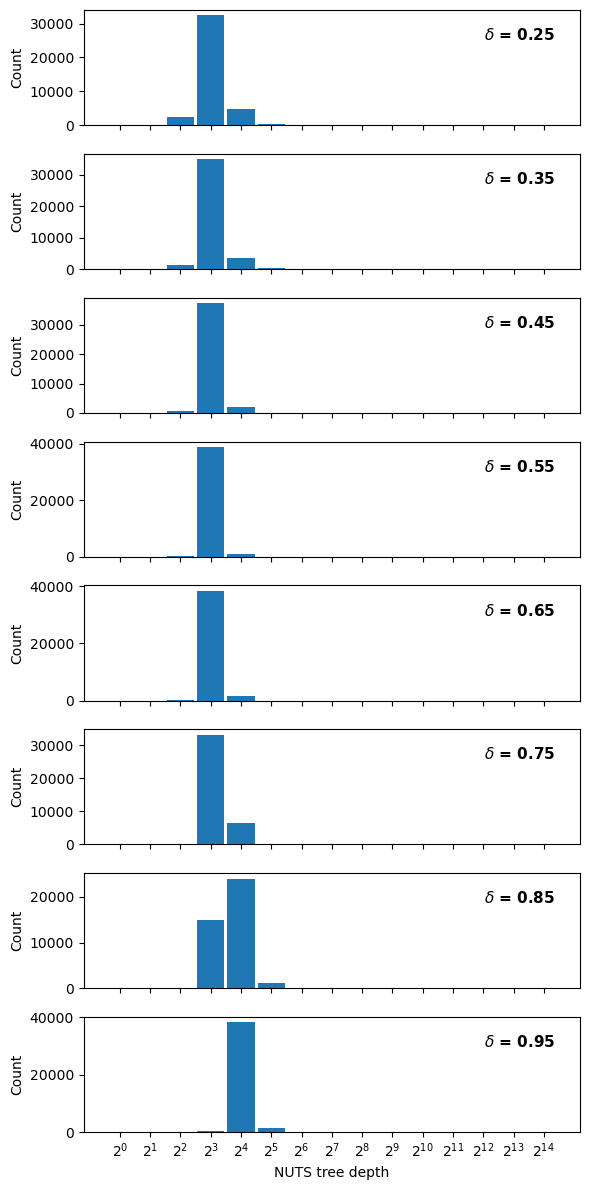

In [24]:
# Possible mode: h-delta; Ess-per-grad; Counts
# Possible model: Gauss; LR; HLR
# Possible sampler: NUTS; HMC
sample_settings = { "max_treedepth" : 14,
                    "chains" : 4,
                    "reps": 10
}
plotter(input_path = "NUTS_LR.pkl", sampler = "NUTS", mode = "h-delta", model = "LR",  sample_settings = sample_settings, saving = False)
plotter(input_path = "NUTS_LR.pkl", sampler = "NUTS", mode = "Ess-per-grad", model = "LR",  sample_settings = sample_settings, saving = False)
plotter(input_path = "NUTS_LR_Counts.npy", sampler = "NUTS", mode = "Counts", model = "LR",  sample_settings = sample_settings, saving = False)

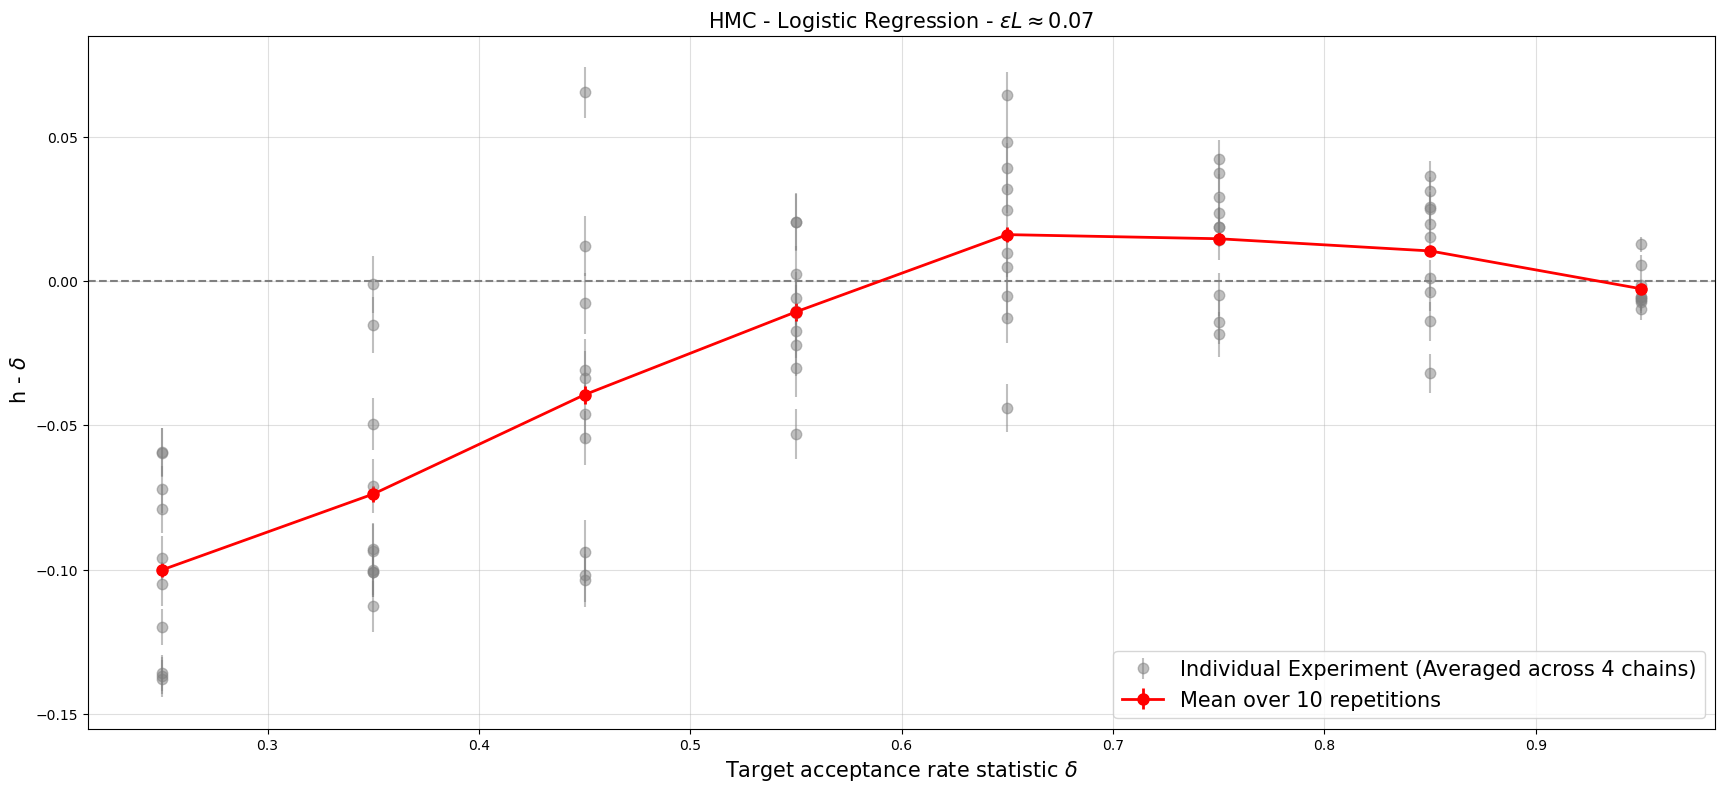

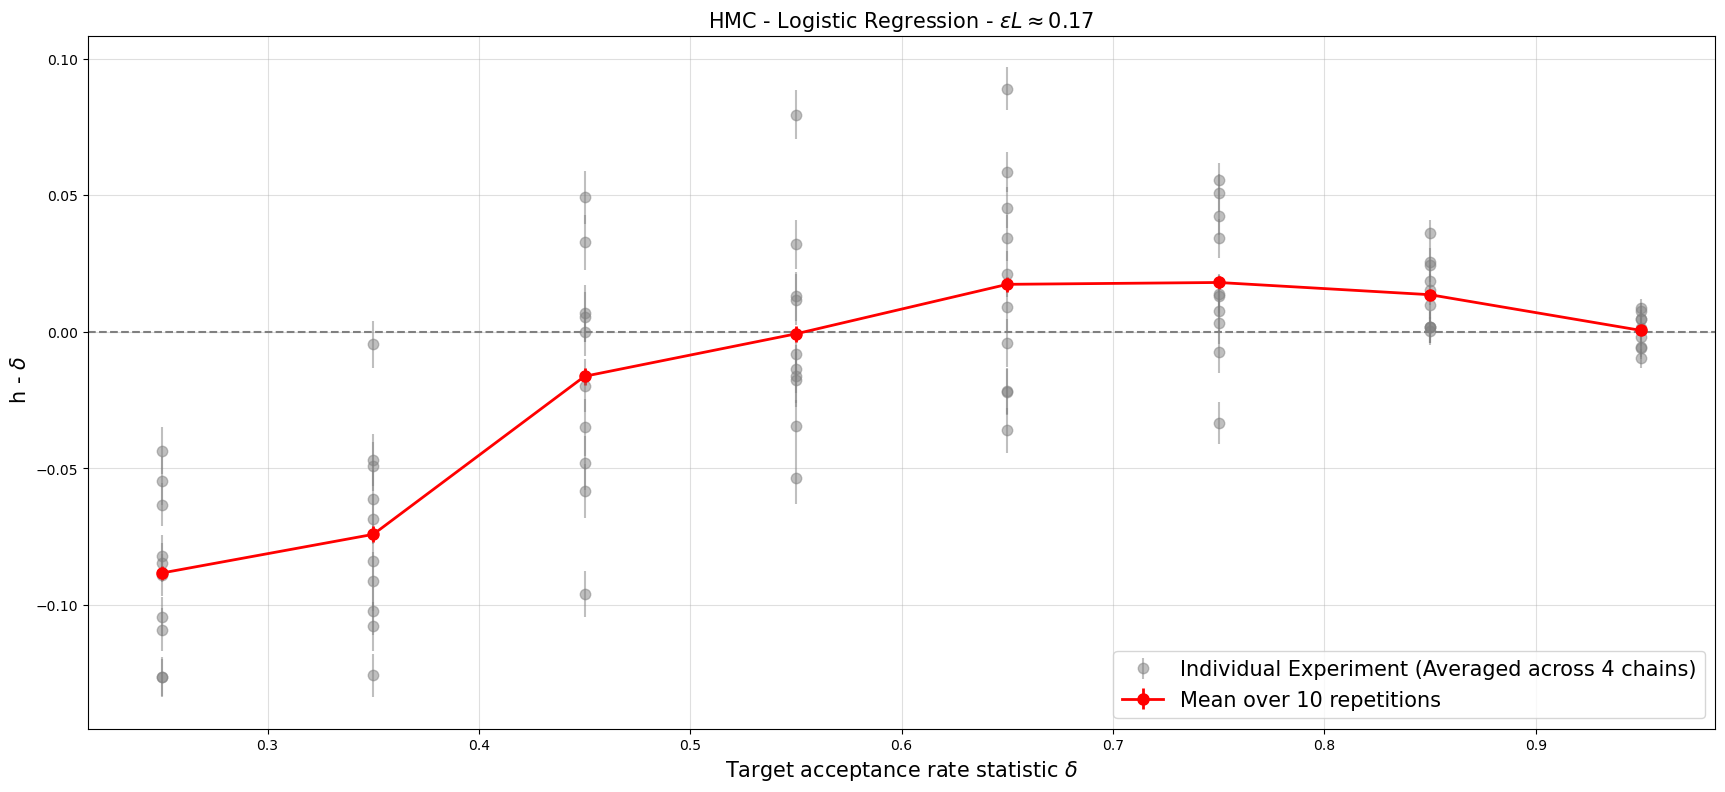

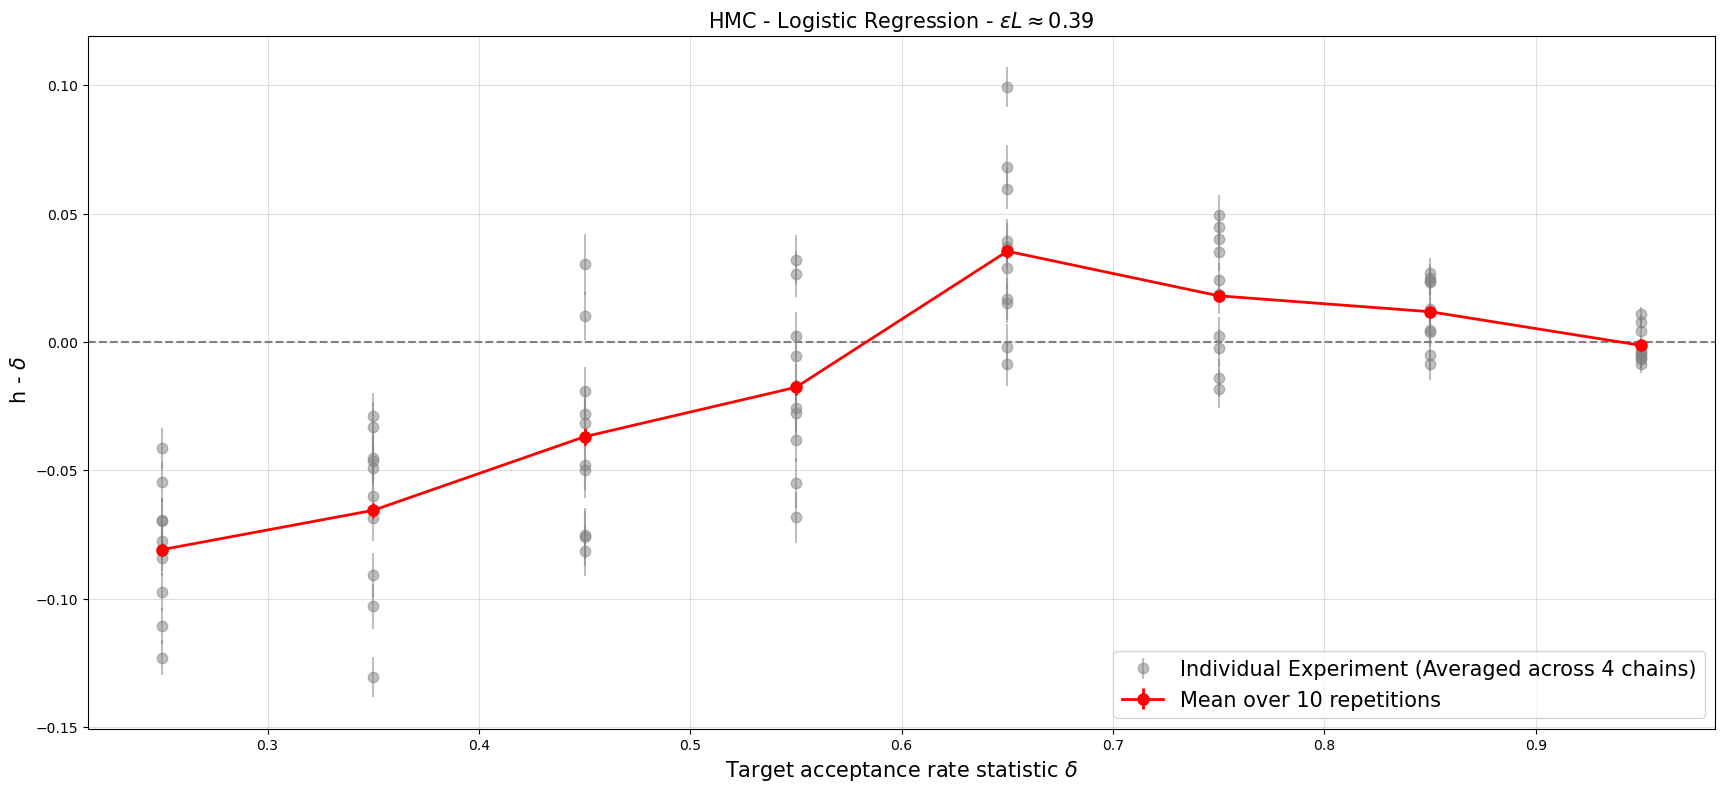

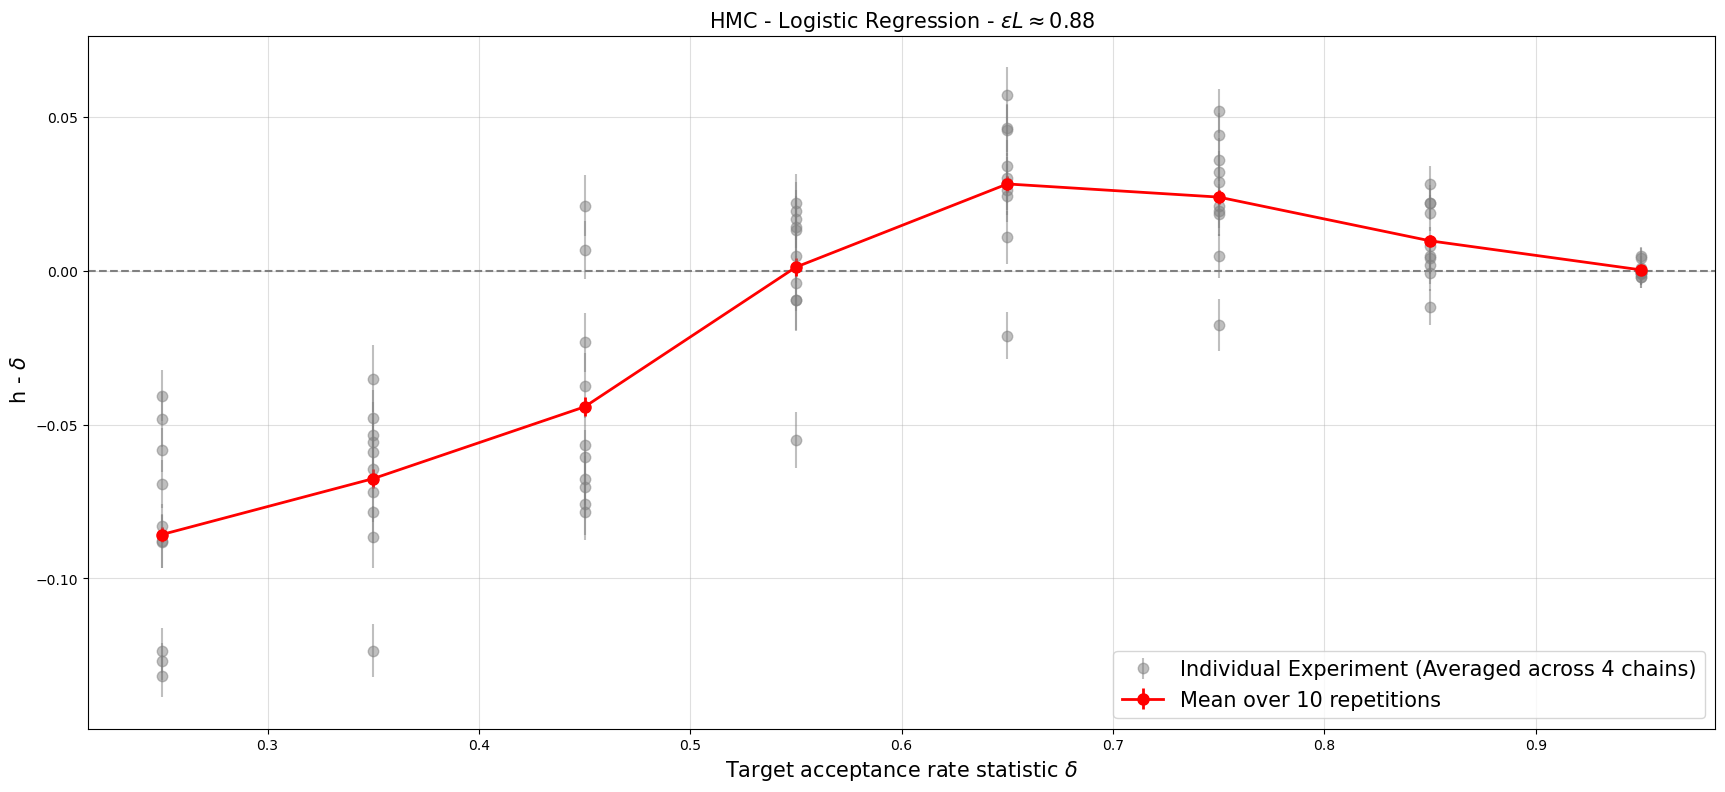

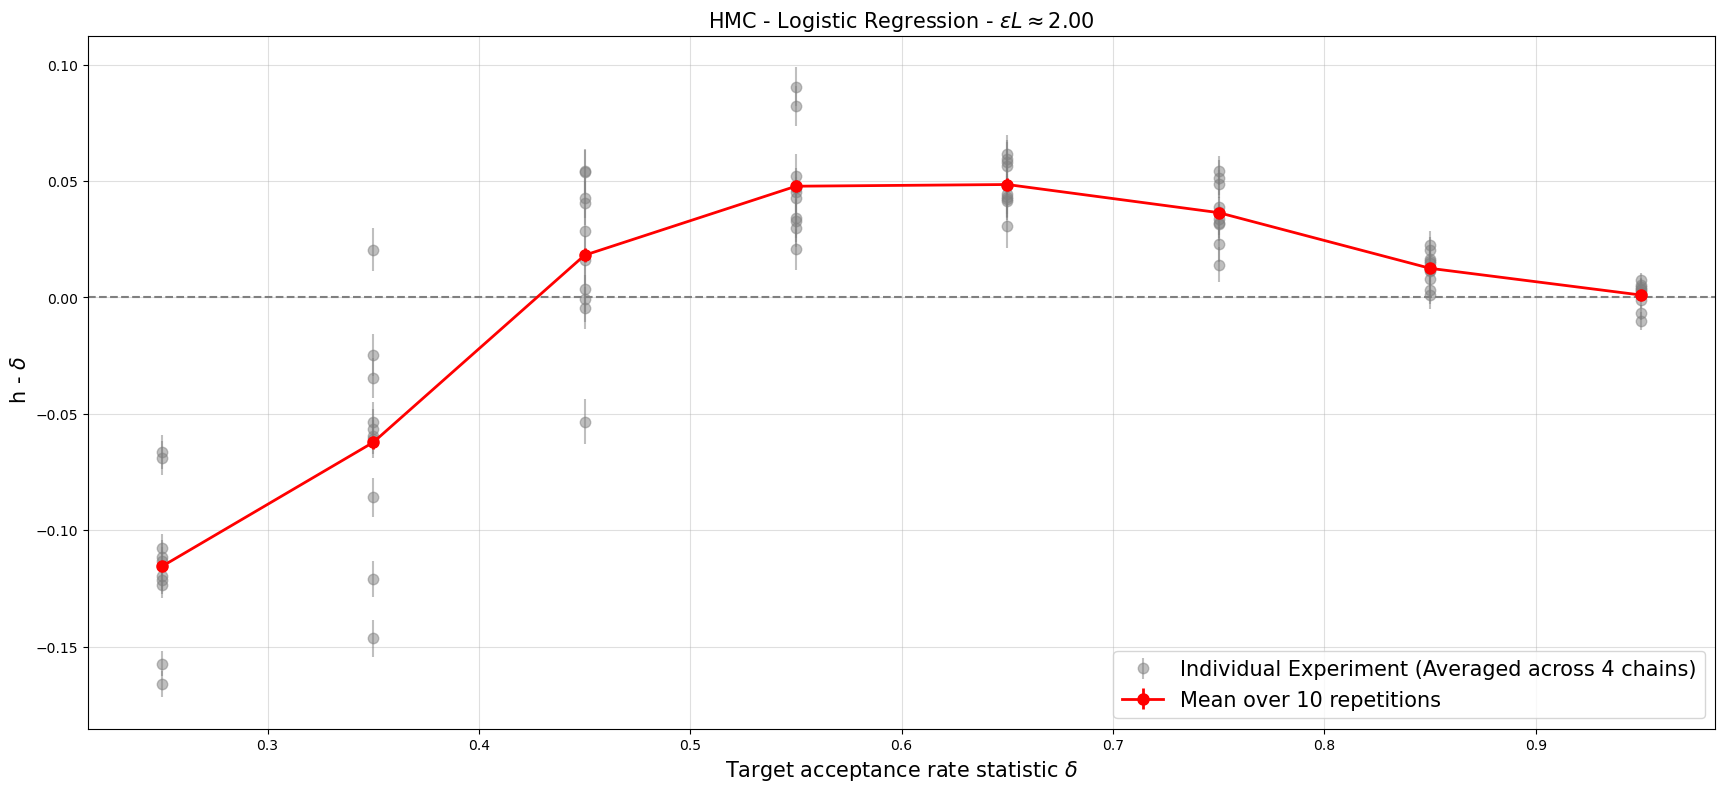

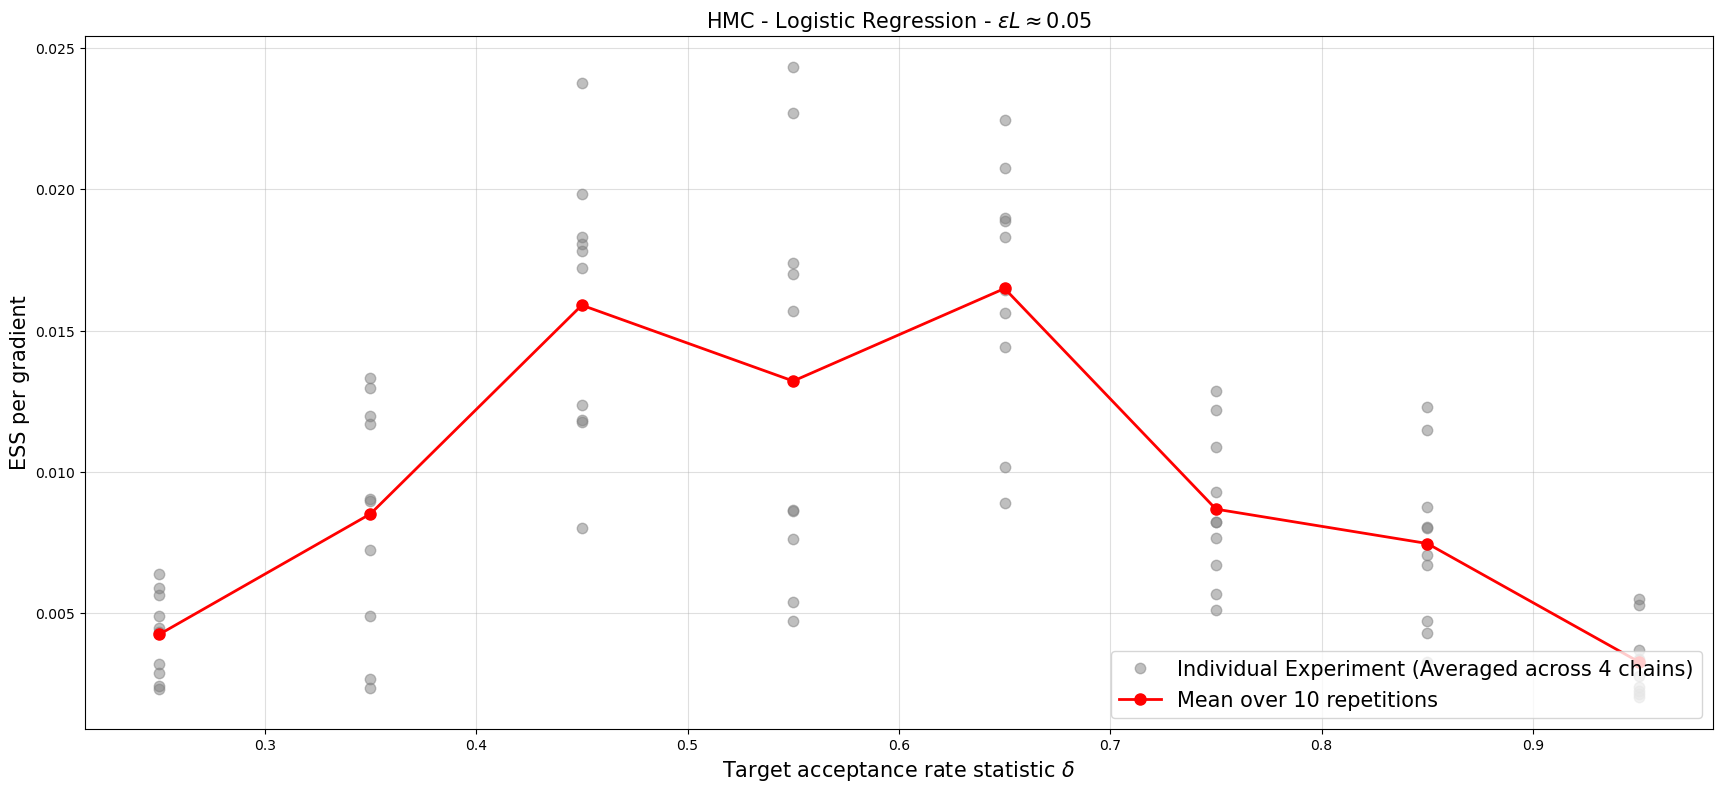

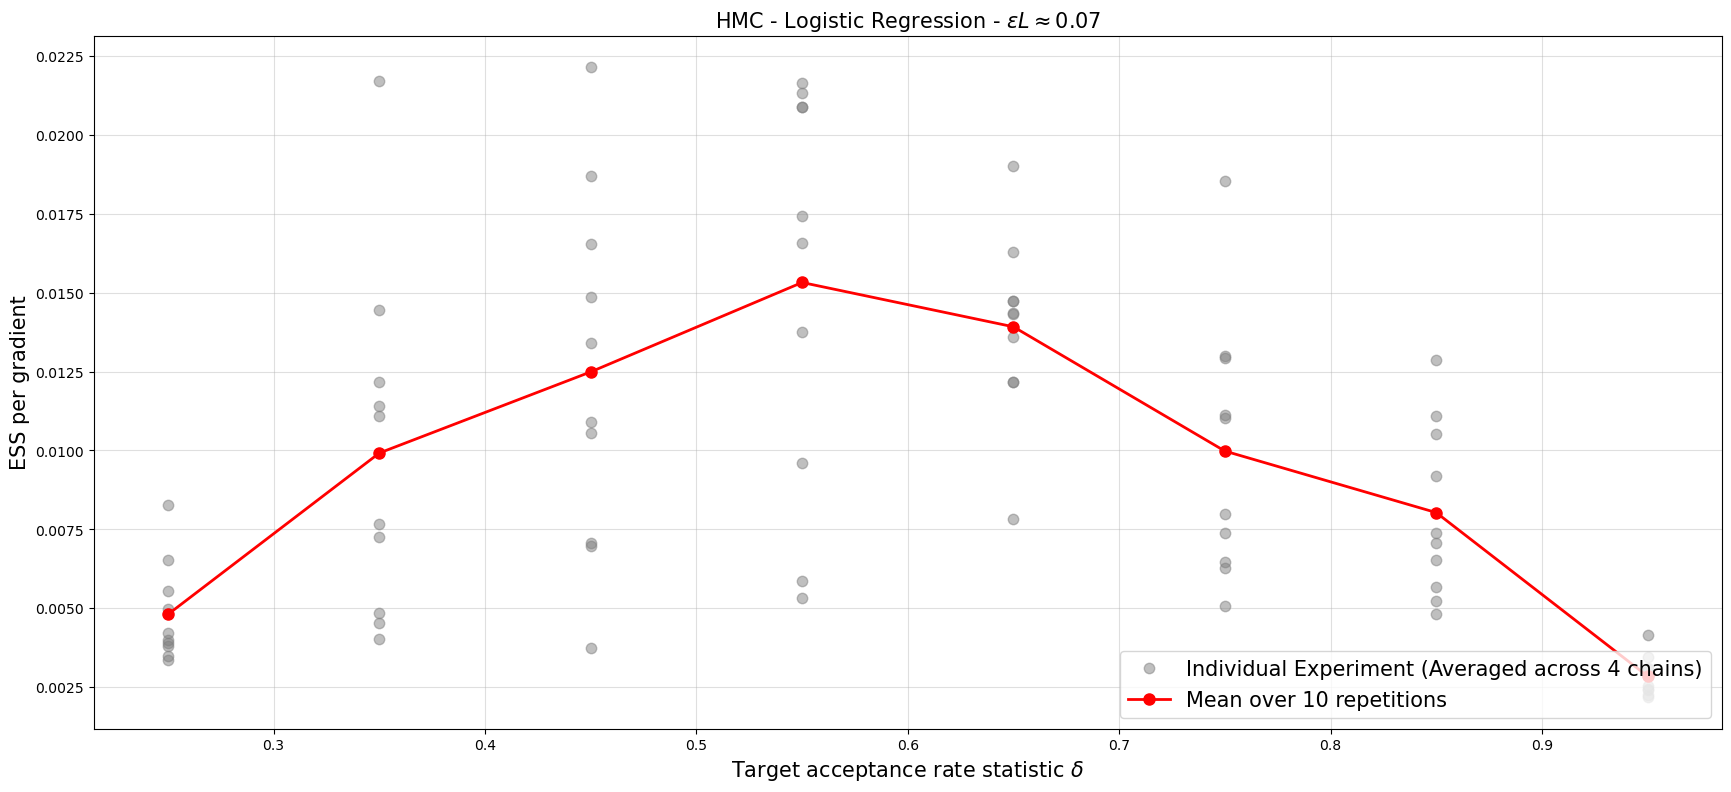

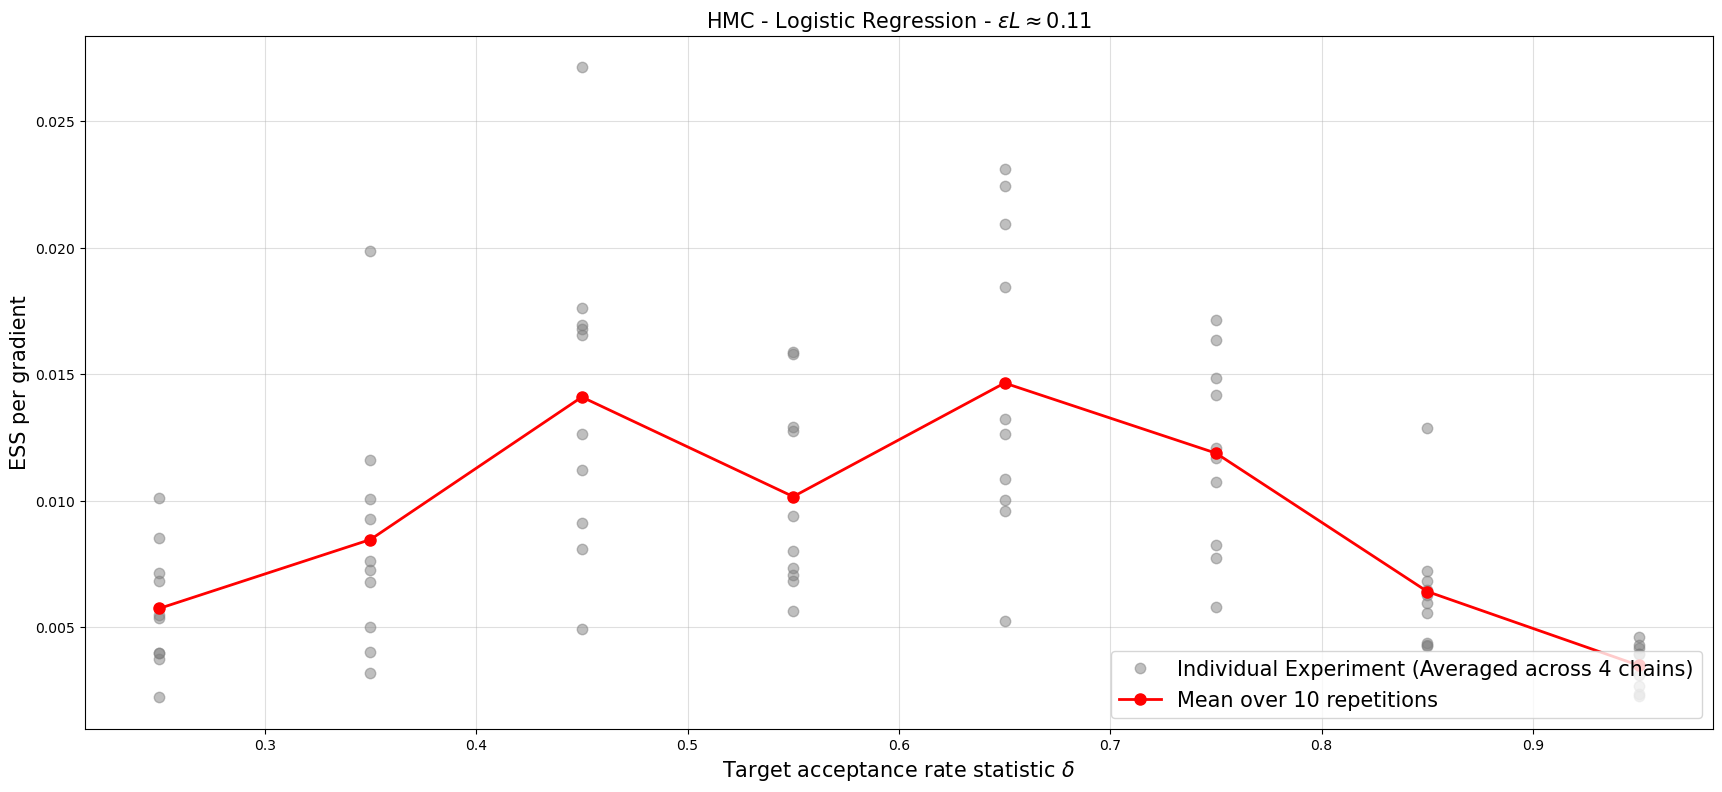

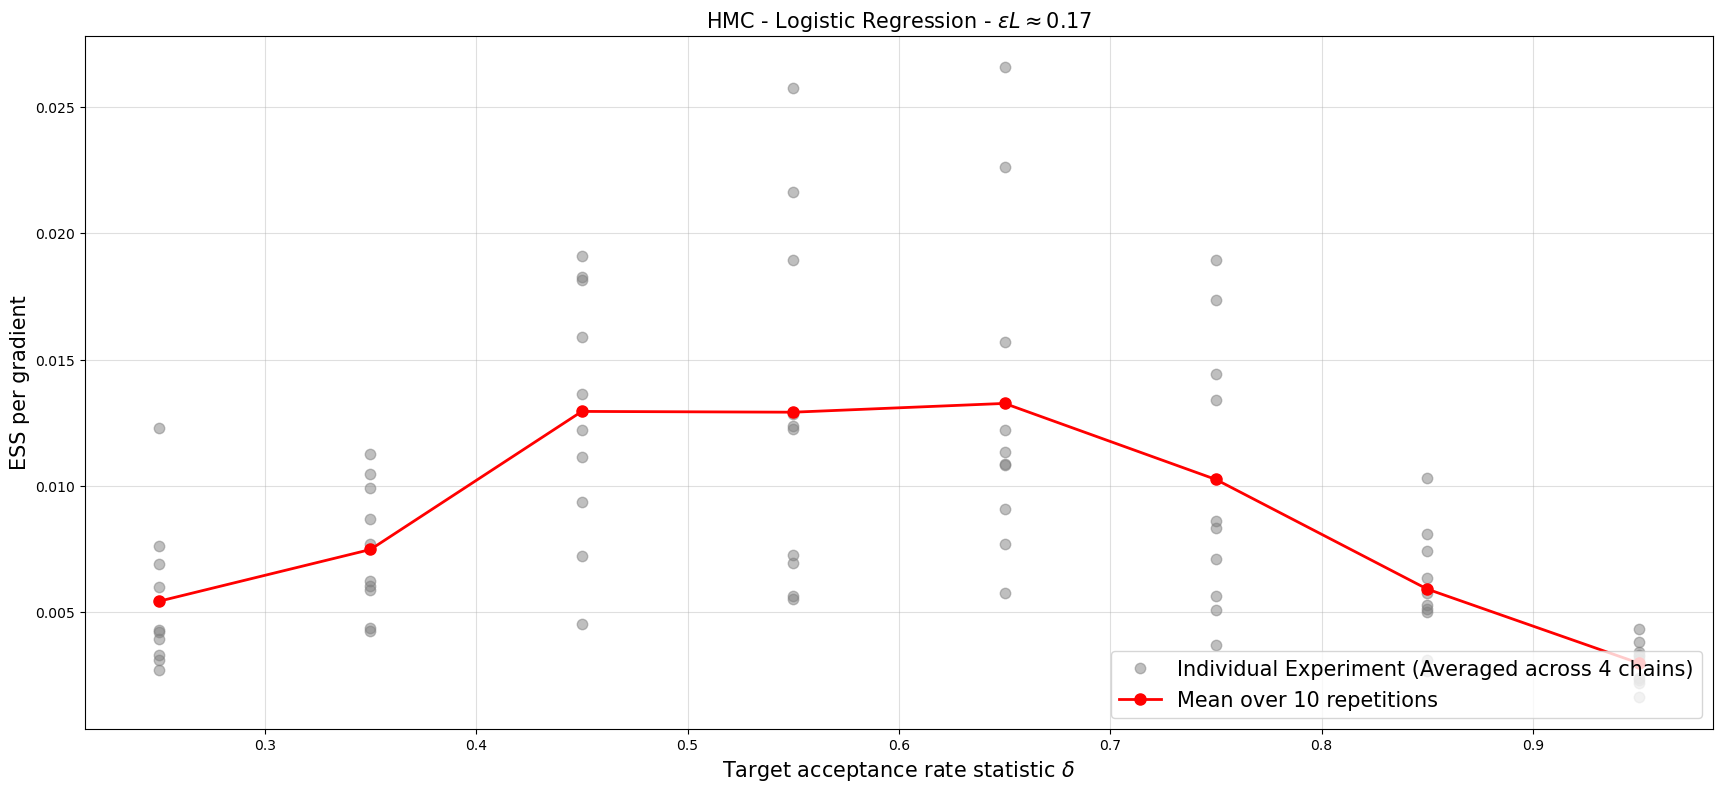

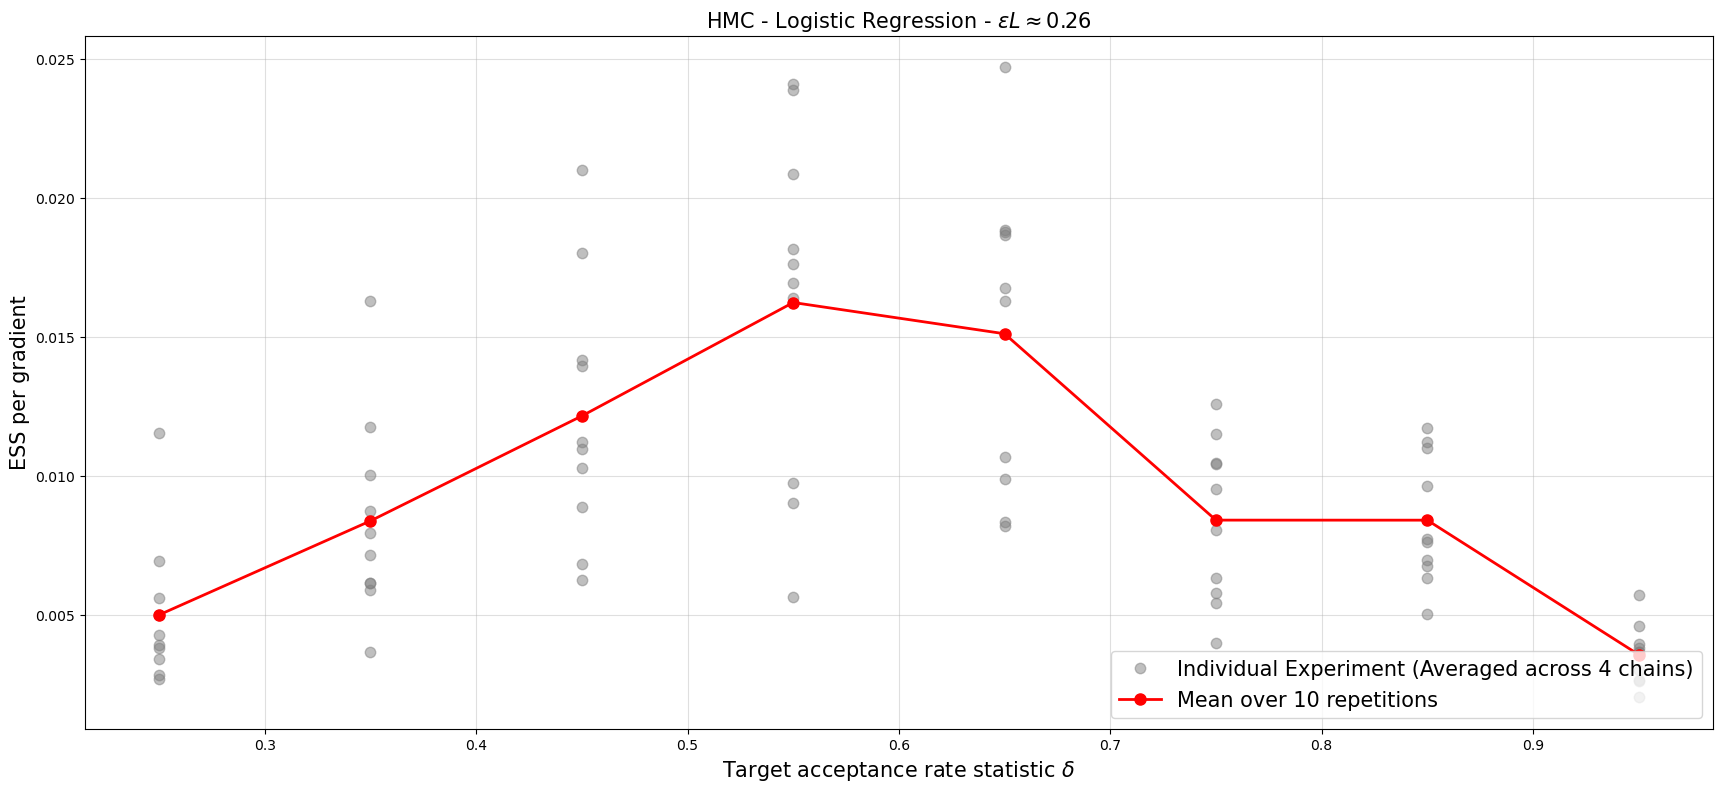

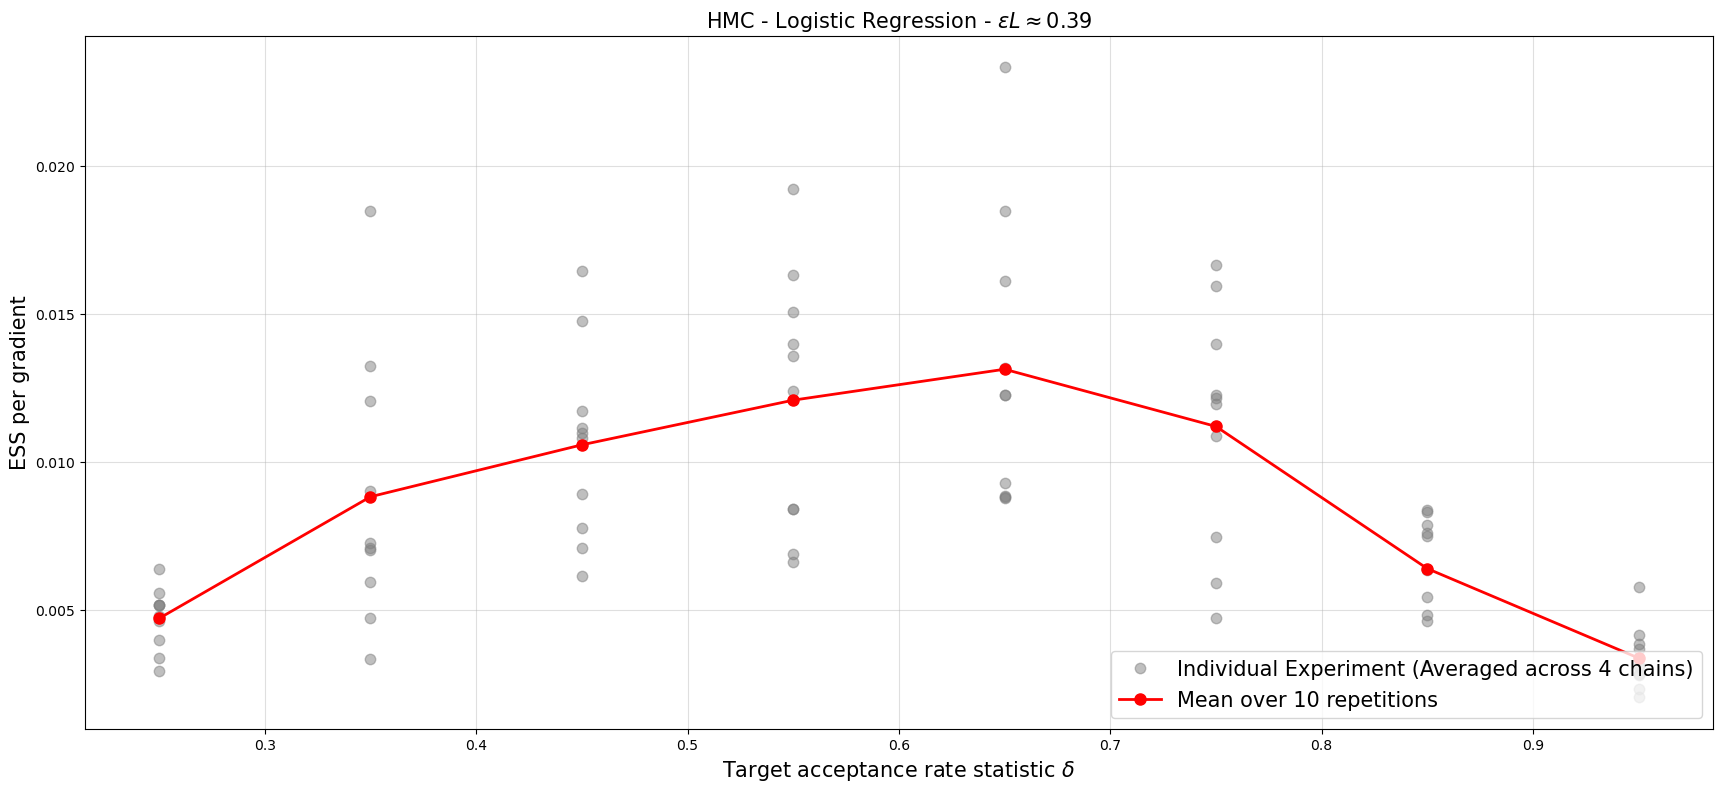

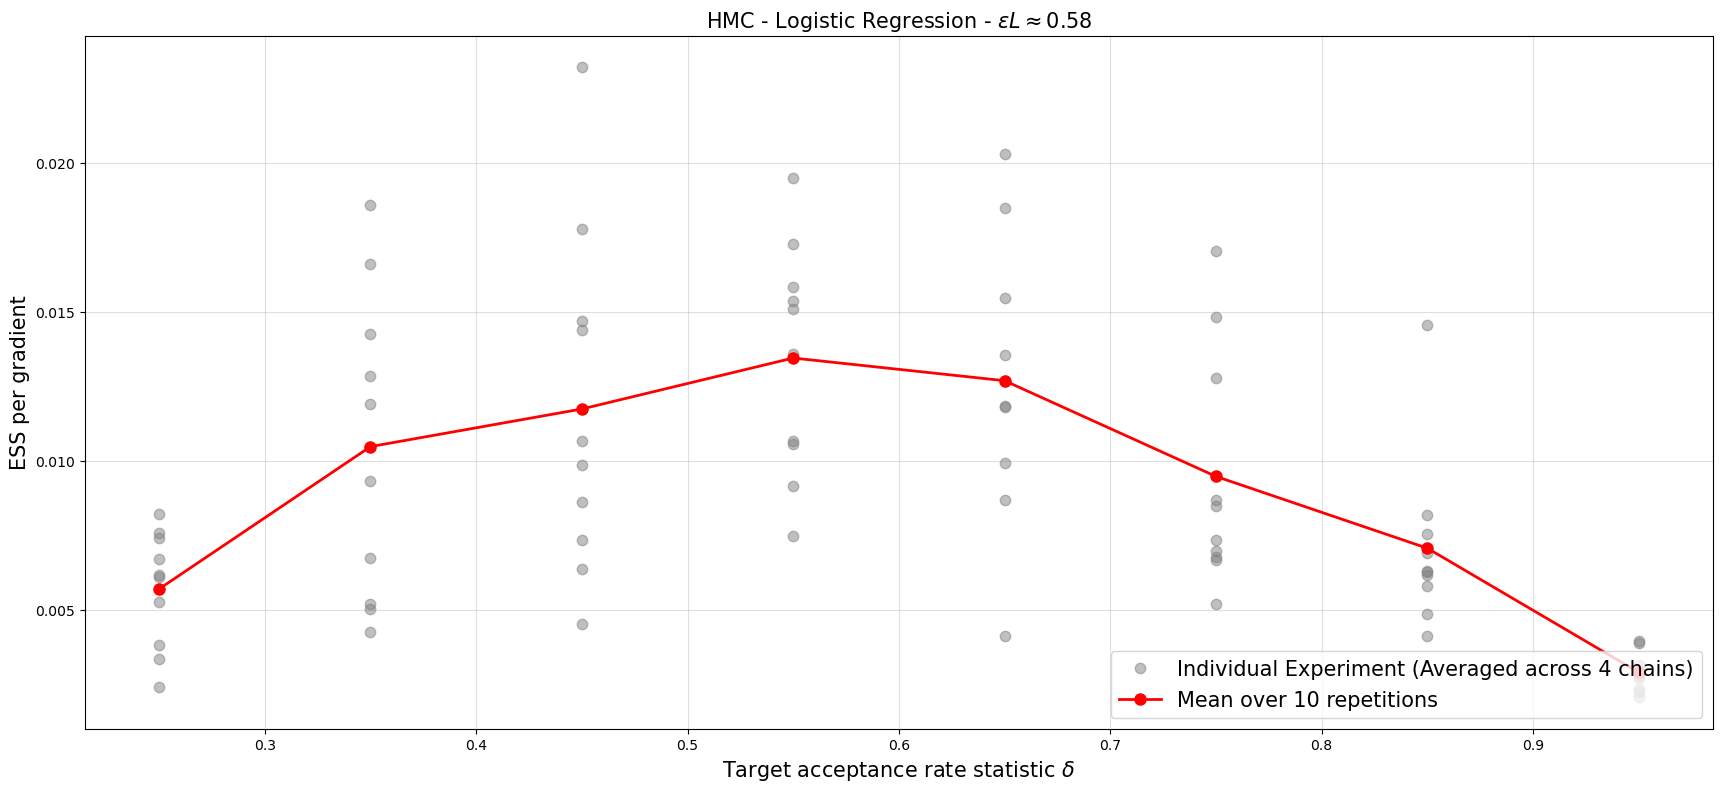

In [25]:
plotter(input_path = "HMC_LR.pkl", sampler = "HMC", mode = "h-delta", model = "LR",  sample_settings = sample_settings, saving = False)
plotter(input_path = "HMC_LR.pkl", sampler = "HMC", mode = "Ess-per-grad", model = "LR",  sample_settings = sample_settings, saving = False)